In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

Libraries imported successfully
Pandas: 3.0.3
NumPy: 2.4.6


In [3]:
# Load all three CSV files
print("📂 Loading Elliptic Bitcoin Dataset...\n")

# Features (166 features + transcaction ID)
features_df = pd.read_csv("../data/elliptic/elliptic_txs_features.csv", header=None)
print(f"✅ Features loaded: {features_df.shape}")

# Labels (transaction ID + class)
labels_df = pd.read_csv("../data/elliptic/elliptic_txs_classes.csv")
print(f"✅ Labels loaded: {labels_df.shape}")

# Edges (transaction connections)
edges_df = pd.read_csv("../data/elliptic/elliptic_txs_edgelist.csv")
print(f"✅ Edges loaded: {edges_df.shape}")

print("\n" + "=" * 60)
print("Dataset loaded successfully.")
print("=" * 60)

📂 Loading Elliptic Bitcoin Dataset...

✅ Features loaded: (203769, 167)
✅ Labels loaded: (203769, 2)
✅ Edges loaded: (234355, 2)

Dataset loaded successfully.


In [4]:
print("🔍 FEATURES DATAFRAME")
print("=" * 60)
print(f"Shape: {features_df.shape}")
print(f"Columns: {features_df.shape[1]}(Column 0 = txId, Column 1 = timestep, Columns 2-166 = features)")
print("\nFirst 5 rows:")
print(features_df.head())

print("\n📊 Basic Statistics (first 10 features):")
print(features_df.iloc[:, 1:11].describe())

🔍 FEATURES DATAFRAME
Shape: (203769, 167)
Columns: 167(Column 0 = txId, Column 1 = timestep, Columns 2-166 = features)

First 5 rows:
         0    1         2         3         4          5         6    \
0  230425980    1 -0.171469 -0.184668 -1.201369  -0.121970 -0.043875   
1    5530458    1 -0.171484 -0.184668 -1.201369  -0.121970 -0.043875   
2  232022460    1 -0.172107 -0.184668 -1.201369  -0.121970 -0.043875   
3  232438397    1  0.163054  1.963790 -0.646376  12.409294 -0.063725   
4  230460314    1  1.011523 -0.081127 -1.201369   1.153668  0.333276   

        7          8         9    ...       157       158       159       160  \
0 -0.113002  -0.061584 -0.162097  ... -0.562153 -0.600999  1.461330  1.461369   
1 -0.113002  -0.061584 -0.162112  ...  0.947382  0.673103 -0.979074 -0.978556   
2 -0.113002  -0.061584 -0.162749  ...  0.670883  0.439728 -0.979074 -0.978556   
3  9.782742  12.414558 -0.163645  ... -0.577099 -0.613614  0.241128  0.241406   
4  1.312656  -0.061584 -0.16

In [5]:
print("🏷️  LABELS DATAFRAME")
print("="*60)
print(f"Shape: {labels_df.shape}")
print(f"Columns:{labels_df.columns.to_list()}")
print("\nFirst 10 rows:")
print(labels_df.head(10))

print("\n📊 Class Distribution:")
class_counts = labels_df['class'].value_counts()
print(class_counts)
total = len(labels_df)
print("\n📈 Percentages:")
for cls, count in class_counts.items():
    print(f" {cls:8s}: {count:6,} ({count/total*100:5.2f}%)")

🏷️  LABELS DATAFRAME
Shape: (203769, 2)
Columns:['txId', 'class']

First 10 rows:
        txId    class
0  230425980  unknown
1    5530458  unknown
2  232022460  unknown
3  232438397        2
4  230460314  unknown
5  230459870  unknown
6  230333930  unknown
7  230595899  unknown
8  232013274  unknown
9  232029206        2

📊 Class Distribution:
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

📈 Percentages:
 unknown : 157,205 (77.15%)
 2       : 42,019 (20.62%)
 1       :  4,545 ( 2.23%)


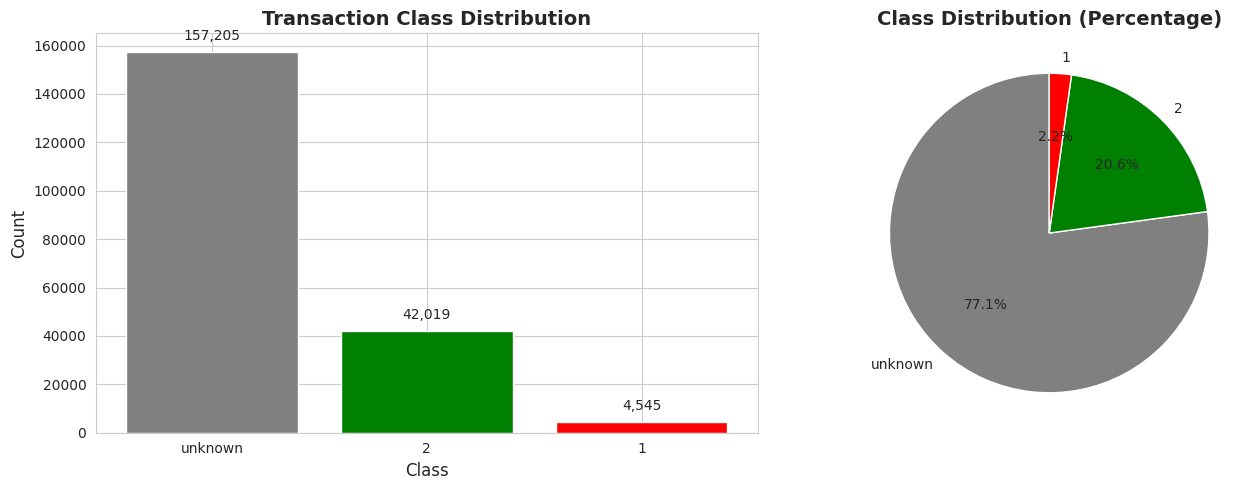


💡 INSIGHT:
Only ~2% of transactions are labeled as illicit!
This is called 'class imbalance' - we'll handle this with SMOTE later.


In [6]:
# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts = labels_df['class'].value_counts()
ax1.bar(class_counts.index, class_counts.values, color=['gray', 'green', 'red'])
ax1.set_xlabel('Class', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(class_counts)))
ax1.set_xticklabels(class_counts.index)

# Add count labels on bars
for i, (cls, count) in enumerate(class_counts.items()):
    ax1.text(i, count + 5000, f'{count:,}', ha='center', fontsize=10)

# Pie chart
colors = ['gray', 'green', 'red']
ax2.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
ax2.set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT:")
print("Only ~2% of transactions are labeled as illicit!")
print("This is called 'class imbalance' - we'll handle this with SMOTE later.")

In [7]:
# Merge features with labels
print("🔗 Merging features and labels...")
features_df = features_df.rename(columns={0: 'txId'})
df = features_df.merge(labels_df, on='txId')
print(f"\n✅ Merged DataFrame Shape: {df.shape}")
print(f"Columns: {df.shape[1]}")
print("\nFirst 3 rows:")
print(df.head(3))
print(f"\n🔍 Missing values: {df.isnull().sum().sum()}")

🔗 Merging features and labels...

✅ Merged DataFrame Shape: (203769, 168)
Columns: 168

First 3 rows:
        txId  1         2         3         4        5         6         7  \
0  230425980  1 -0.171469 -0.184668 -1.201369 -0.12197 -0.043875 -0.113002   
1    5530458  1 -0.171484 -0.184668 -1.201369 -0.12197 -0.043875 -0.113002   
2  232022460  1 -0.172107 -0.184668 -1.201369 -0.12197 -0.043875 -0.113002   

          8         9  ...       158       159       160       161       162  \
0 -0.061584 -0.162097  ... -0.600999  1.461330  1.461369  0.018279 -0.087490   
1 -0.061584 -0.162112  ...  0.673103 -0.979074 -0.978556  0.018279 -0.087490   
2 -0.061584 -0.162749  ...  0.439728 -0.979074 -0.978556 -0.098889 -0.106715   

        163       164       165       166    class  
0 -0.131155 -0.097524 -0.120613 -0.119792  unknown  
1 -0.131155 -0.097524 -0.120613 -0.119792  unknown  
2 -0.131155 -0.183671 -0.120613 -0.119792  unknown  

[3 rows x 168 columns]

🔍 Missing values: 0


⏰ TIME STEP ANALYSIS (Feature 1)
Min time step: 1
Max time step: 49
Number of unique time steps: 49


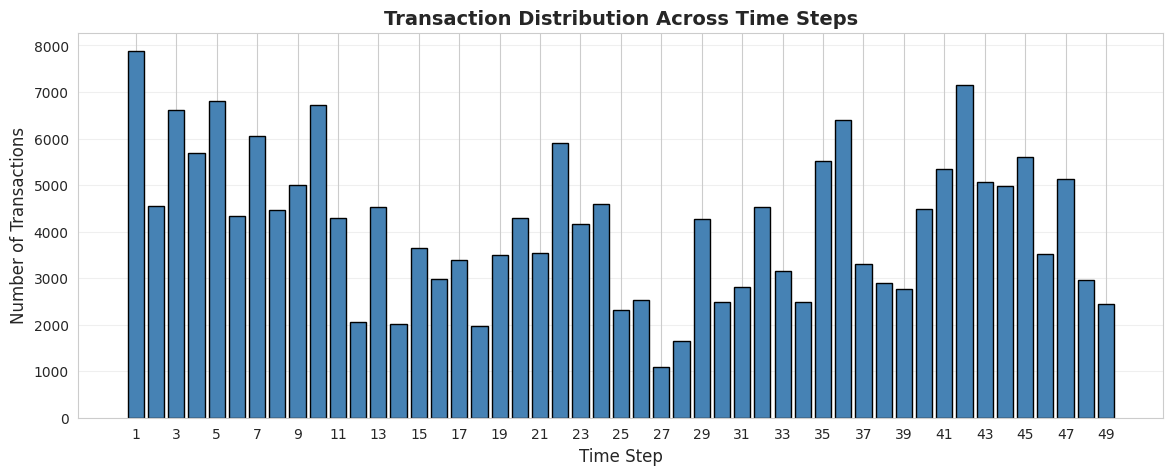


💡 INSIGHT:
Time steps 1-49 represent ~3 years of Bitcoin transactions
Each time step ≈ 2 weeks of real time


In [8]:
print("⏰ TIME STEP ANALYSIS (Feature 1)")
print("="*60)

print(f"Min time step: {df[1].min()}")
print(f"Max time step: {df[1].max()}")
print(f"Number of unique time steps: {df[1].nunique()}")

# Transactions per time step
time_dist = df[1].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(time_dist.index, time_dist.values, color='steelblue', edgecolor='black')
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.title('Transaction Distribution Across Time Steps', fontsize=14, fontweight='bold')
plt.xticks(range(1, 50, 2))
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n💡 INSIGHT:")
print("Time steps 1-49 represent ~3 years of Bitcoin transactions")
print("Each time step ≈ 2 weeks of real time")

In [9]:
print("✅ Labeled DataFrame with only known class transaction:")
labeled_df = df[df['class'] != 'unknown'].copy()
labeled_df['is_illicit'] = (labeled_df['class'] == '1').astype(int)
print(labeled_df.head(5))
print("📊 LABELED DATA ANALYSIS")
print("="*60)
print(f"Total labeled transactions: {len(labeled_df):,}")
print(f"  - Illicit (class 1): {(labeled_df['is_illicit'] == 1).sum():,}")
print(f"  - Licit (class 2): {(labeled_df['is_illicit'] == 0).sum():,}")
print(f"\n⚖️  Class Imbalance Ratio: {(labeled_df['is_illicit'] == 1).sum() / (labeled_df['is_illicit'] == 0).sum():.1f}:1")
print("   (For every 1 illicit transaction, there are ~9 licit ones)")

# Labeled data by time step
labeled_by_time = labeled_df.groupby(1)['is_illicit'].agg(['count', 'sum', 'mean'])
labeled_by_time.columns = ['total', 'illicit_count', 'illicit_rate']
#print(f"\n📅 Time steps with labeled data: {sorted(labeled_df[1].unique())}")
print(f"Labeled data grouped by time step\n{labeled_by_time}")
print("="*60)
print("Top 5 time steps by illicit to licit ratio:")
top5_illicit_ratio = labeled_by_time.sort_values(by='illicit_rate', ascending=False).head(5)
print(top5_illicit_ratio)


✅ Labeled DataFrame with only known class transaction:
         txId  1         2         3         4          5         6         7  \
3   232438397  1  0.163054  1.963790 -0.646376  12.409294 -0.063725  9.782742   
9   232029206  1 -0.005027  0.578941 -0.091383   4.380281 -0.063725  4.667146   
10  232344069  1 -0.147852 -0.184668 -1.201369  -0.121970 -0.043875 -0.113002   
11   27553029  1 -0.151357 -0.184668 -1.201369  -0.121970 -0.043875 -0.113002   
16    3881097  1 -0.172306 -0.184668 -1.201369   0.028105 -0.043875 -0.029140   

            8         9  ...       159       160       161       162  \
3   12.414558 -0.163645  ...  0.241128  0.241406  1.072793  0.085530   
9    0.851305 -0.163645  ...  0.241128  0.241406  0.604120  0.008632   
10  -0.061584 -0.137933  ...  0.241128  0.241406  0.018279 -0.087490   
11  -0.061584 -0.141519  ... -0.979074 -0.978556  0.018279 -0.087490   
16   0.242712 -0.163640  ...  0.241128  0.241406  0.018279 -0.068266   

         163       164   

📊 FEATURE DISTRIBUTION COMPARISON


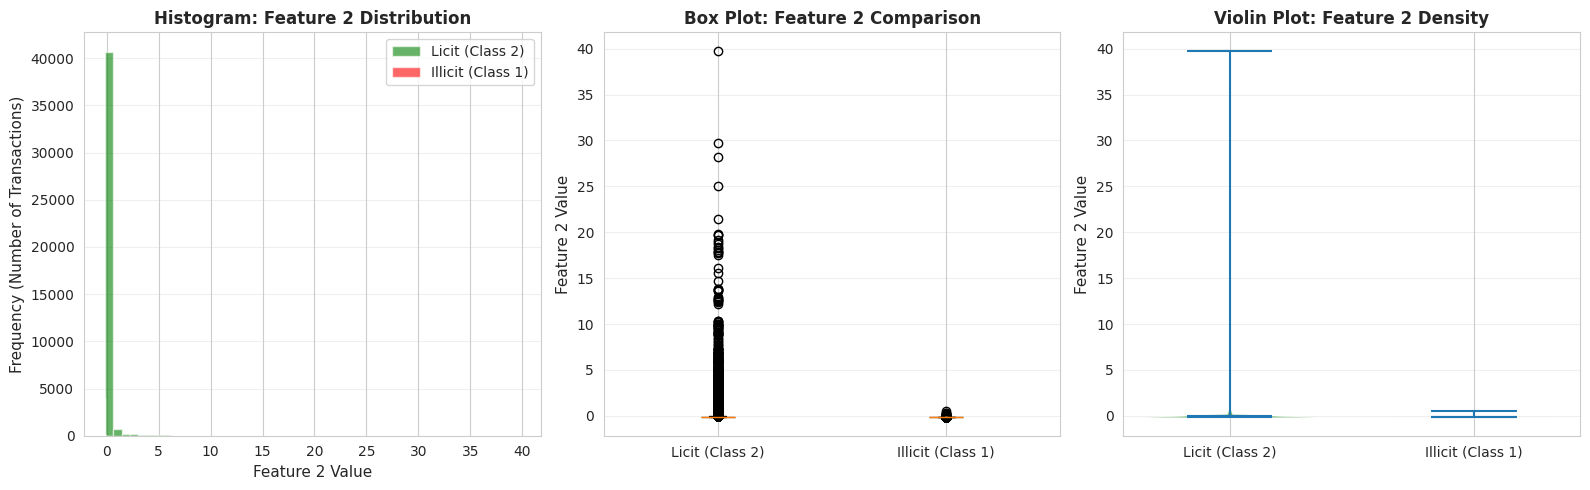


💡 INTERPRETATION GUIDE:
────────────────────────────────────────────────────────────
 What to Look For:
  ✅ GOOD: Distributions clearly separated (different positions)
  ⚠️  OKAY: Distributions partially overlap (some separation)
  ❌ BAD: Distributions completely overlap (no separation)

 What Each Chart Shows:
  • Histogram: Raw counts at each value
  • Box Plot: Median, quartiles, and outliers
  • Violin Plot: Smooth density distribution

 For This Feature:
  • Licit mean: -0.0404
  • Illicit mean: -0.1657
  • Difference: 0.1253
  → 🟢 GOOD FEATURE (means are different!)


In [10]:
# Compare feature distributions between licit and illicit
print("📊 FEATURE DISTRIBUTION COMPARISON")
print("="*60)

# Let's look at Feature 2 (first actual feature after time step)
feature_col = 2

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# HISTOGRAM - Shows frequency distribution
# Green = Licit (class 2), Red = Illicit (class 1)
axes[0].hist(labeled_df[labeled_df['is_illicit'] == 0][feature_col], 
             bins=50, alpha=0.6, label='Licit (Class 2)', color='green')
axes[0].hist(labeled_df[labeled_df['is_illicit'] == 1][feature_col], 
             bins=50, alpha=0.6, label='Illicit (Class 1)', color='red')
axes[0].set_xlabel(f'Feature {feature_col} Value', fontsize=11)
axes[0].set_ylabel('Frequency (Number of Transactions)', fontsize=11)
axes[0].set_title(f'Histogram: Feature {feature_col} Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# BOX PLOT - Shows median, quartiles, and outliers
data_to_plot = [
    labeled_df[labeled_df['is_illicit'] == 0][feature_col],
    labeled_df[labeled_df['is_illicit'] == 1][feature_col]
]
bp = axes[1].boxplot(data_to_plot, tick_labels=['Licit (Class 2)', 'Illicit (Class 1)'],
                      patch_artist=True)
# Color the boxes
colors = ['green', 'red']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_ylabel(f'Feature {feature_col} Value', fontsize=11)
axes[1].set_title(f'Box Plot: Feature {feature_col} Comparison', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# VIOLIN PLOT - Shows density/shape of distribution
parts = axes[2].violinplot([labeled_df[labeled_df['is_illicit'] == 0][feature_col],
                             labeled_df[labeled_df['is_illicit'] == 1][feature_col]],
                            positions=[1, 2], showmeans=True, widths=0.7)
# Color the violins
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(['green', 'red'][i])
    pc.set_alpha(0.6)
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(['Licit (Class 2)', 'Illicit (Class 1)'])
axes[2].set_ylabel(f'Feature {feature_col} Value', fontsize=11)
axes[2].set_title(f'Violin Plot: Feature {feature_col} Density', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETATION GUIDE:")
print("─" * 60)
print(" What to Look For:")
print("  ✅ GOOD: Distributions clearly separated (different positions)")
print("  ⚠️  OKAY: Distributions partially overlap (some separation)")
print("  ❌ BAD: Distributions completely overlap (no separation)")
print()
print(" What Each Chart Shows:")
print("  • Histogram: Raw counts at each value")
print("  • Box Plot: Median, quartiles, and outliers")
print("  • Violin Plot: Smooth density distribution")
print()
print(" For This Feature:")
licit_mean = labeled_df[labeled_df['is_illicit'] == 0][feature_col].mean()
illicit_mean = labeled_df[labeled_df['is_illicit'] == 1][feature_col].mean()
print(f"  • Licit mean: {licit_mean:.4f}")
print(f"  • Illicit mean: {illicit_mean:.4f}")
print(f"  • Difference: {abs(licit_mean - illicit_mean):.4f}")
if abs(licit_mean - illicit_mean) > 0.1:
    print("  → 🟢 GOOD FEATURE (means are different!)")
else:
    print("  → 🔴 WEAK FEATURE (means are similar)")

In [11]:
print("="*80)
print(" "*20 + "ELLIPTIC DATASET SUMMARY")
print("="*80)

print(f"\n📊 DATASET SIZE:")
print(f"  Total transactions: {len(df):,}")
print(f"  Features per transaction: 166")
print(f"  Time steps: {df[1].min()} to {df[1].max()}")

print(f"\n🏷️  LABELS:")
print(f"  Labeled transactions: {len(labeled_df):,} ({len(labeled_df)/len(df)*100:.1f}%)")
print(f"    - Licit: {(labeled_df['is_illicit'] == 0).sum():,}")
print(f"    - Illicit: {(labeled_df['is_illicit'] == 1).sum():,}")
print(f"  Unlabeled transactions: {(df['class'] == 'unknown').sum():,} ({(df['class'] == 'unknown').sum()/len(df)*100:.1f}%)")

print(f"\n🔗 GRAPH STRUCTURE:")
print(f"  Transaction edges: {len(edges_df):,}")
print(f"  (Edges represent money flow between transactions)")

print("\n" + "="*80)
print("✅ DATASET EXPLORATION COMPLETE!")
print("="*80)

print("\n📝 KEY TAKEAWAYS:")
print("  1. We have 203,769 Bitcoin transactions")
print("  2. Only 22.6% are labeled (rest are unknown)")
print("  3. Only 2% of labeled transactions are illicit (class imbalance!)")
print("  4. We have 166 features per transaction")
print("  5. Features show different distributions for licit vs illicit")
print("  6. This data is PERFECT for training ML models!")

                    ELLIPTIC DATASET SUMMARY

📊 DATASET SIZE:
  Total transactions: 203,769
  Features per transaction: 166
  Time steps: 1 to 49

🏷️  LABELS:
  Labeled transactions: 46,564 (22.9%)
    - Licit: 42,019
    - Illicit: 4,545
  Unlabeled transactions: 157,205 (77.1%)

🔗 GRAPH STRUCTURE:
  Transaction edges: 234,355
  (Edges represent money flow between transactions)

✅ DATASET EXPLORATION COMPLETE!

📝 KEY TAKEAWAYS:
  1. We have 203,769 Bitcoin transactions
  2. Only 22.6% are labeled (rest are unknown)
  3. Only 2% of labeled transactions are illicit (class imbalance!)
  4. We have 166 features per transaction
  5. Features show different distributions for licit vs illicit
  6. This data is PERFECT for training ML models!
